# Notebook 11 — AlphaFold and Protein Language Models

**Module:** 14 — Deep Learning and GNNs  
**Tier:** 2 — Working competence  
**Notebook:** 11 of 12  
**Time estimate:** 75 minutes

> AlphaFold2 solved protein structure prediction — one of biology's grand challenges.
> ESM-2 produces protein embeddings that capture evolutionary information
> without requiring an MSA. You do not need to implement either — but you must
> be able to explain their key architectural innovations and use them for
> downstream tasks.

---
## Step 1 — Motivation

Before AlphaFold2 (2021): 50 years of experimental effort had determined
structures for ~170,000 proteins. AlphaFold2 predicts structure for any
protein from sequence alone, with near-experimental accuracy. ESM-2 represents
proteins as dense embeddings that encode evolutionary and structural information
without requiring a pre-computed multiple sequence alignment — making it
practical for de novo protein design and fast annotation of novel proteins.

---
## Step 2 — Intuition

**AlphaFold2 pipeline (conceptual):**
1. **Input:** protein sequence + MSA (multiple sequence alignment)
2. **Evoformer:** iterative attention over the MSA (row + column attention)
   and over the residue pair representation (triangular updates)
   → produces a 3D-informed residue and pair embedding
3. **Structure module:** takes the embeddings and iteratively refines
   a set of rigid body frames (backbone N-Cα-C triplets)
   using invariant point attention (IPA) — respects 3D geometry
4. **Recycling:** run the full pipeline 3 times, feeding the current structure
   estimate back as input
5. **Output:** 3D coordinates (backbone + side chains) + per-residue confidence (pLDDT)

**pLDDT score:** per-residue confidence 0–100. >90 = high confidence.
Low pLDDT ≠ wrong prediction — it often indicates intrinsically disordered regions.

**ESM-2 (protein language model):**
- Transformer trained with masked language modeling on 250M protein sequences
- No MSA required — single-sequence input
- Output: per-residue embeddings that implicitly encode:
  - Secondary structure
  - Contact maps (coevolutionary information)
  - Functional sites

**Zero-shot variant effect prediction:**
Compute the log-likelihood ratio of mutant vs. wildtype sequence under the language model:
$\text{LLR}(x_\text{mut}) = \log P(x_\text{mut}) - \log P(x_\text{wt})$
Without any fine-tuning, this LLR correlates with experimental fitness (DMS data) at $r \approx 0.6$.

---
## Step 3 — Biological Background

**AlphaFold2 key innovations (Jumper 2021, Nature):**
1. **Evoformer block:** simultaneous attention over the MSA (sequence × alignment) and
   residue pairs (sequence × sequence). Triangular attention enforces geometric
   consistency: if residue $i$ is close to $j$, and $j$ is close to $k$, then
   $i$ should be somewhat close to $k$.
2. **Invariant point attention (IPA):** attention that respects 3D Euclidean symmetry
   — rotations and translations of the input structure produce the same attention output.
3. **End-to-end training:** loss computed directly on 3D coordinates (FAPE loss —
   frame-aligned point error) rather than on distance matrices.
4. **Recycling:** run 3 iterations of the full pipeline, with previous coordinates
   as additional input features.

**ESM-2 (Lin 2023, Science):**
- Scales from 8M to 15B parameters
- Attention heads at the last layer encode contact maps — coevolution from MSA
  captured implicitly from single sequences by scale
- ESMFold: uses ESM-2 embeddings + lightweight structure module → AlphaFold-quality
  structures without MSA computation (100× faster)

**ColabFold (Mirdita 2022, Nature Methods):**
Practical AlphaFold2 access. Uses MMseqs2 for fast MSA construction.
Free via Google Colab. ~5 minutes per protein.

**Clinical/research impact:**
- AlphaFold Protein Structure Database: 200M+ structures (entire UniProt)
- Drug discovery: structure-based design now possible for any target
- Orphan disease: structure explains variant pathogenicity
- Protein design: ProteinMPNN + RFdiffusion use AlphaFold quality-checking

---
## Step 4 — Mathematical Explanation

**FAPE loss (Frame-Aligned Point Error):**
$$\mathcal{L}_{FAPE} = \frac{1}{N_\text{frames}} \frac{1}{N_\text{atoms}} \sum_{l,i} \left\| T_l^{-1}(\mathbf{x}_i) - T_l^{\text{true}-1}(\mathbf{x}_i^\text{true}) \right\|^2$$

where $T_l$ is the local frame of residue $l$ (a rotation + translation).
Computing error relative to local frames rather than global coordinates makes the
loss invariant to global rotation/translation of the structure.

**Triangular multiplicative update (evoformer):**
For pair representation $Z_{ij}$:
$$Z_{ij}^{\text{new}} = \text{gate} \cdot \text{Linear}\left(\sum_k Z_{ik} \odot Z_{jk}\right)$$

This propagates information through triplets of residues — if $i$-$k$ and $j$-$k$
are known to be close, it updates the $i$-$j$ pair accordingly.

**ESM-2 masked language model:**
Mask 15% of residues in a protein sequence. Train to predict the masked residue:
$$\mathcal{L}_{MLM} = -\sum_{i \in M} \log P(x_i | x_{\backslash M})$$
where $M$ is the set of masked positions. This objective forces the model to learn
the constraints on which amino acids can occur at each position — an implicit
representation of evolutionary constraints.

In [2]:
# Step 6 — Python: ESM-2 embeddings for protein property prediction
# This notebook uses the ESM library if available, or simulates the embeddings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import torch
torch.manual_seed(42); np.random.seed(42)

# ---- Attempt ESM-2 inference (graceful fallback to simulated) ----
try:
    import esm
    # Load ESM-2 (smallest model: esm2_t6_8M)
    esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
    batch_converter = alphabet.get_batch_converter()
    esm_model.eval()
    ESM_AVAILABLE = True
    print('ESM-2 loaded successfully (8M parameter model)')
except (ImportError, Exception) as e:
    ESM_AVAILABLE = False
    print(f'ESM not available ({e}). Using simulated embeddings.')

# ---- Protein dataset: thermostability prediction ----
# 20 synthetic proteins with known (simulated) melting temperature
AA = 'ACDEFGHIKLMNPQRSTVWY'
rng = np.random.default_rng(42)
N_PROTEINS = 60
PROT_LEN = 80

# Simulated thermostable proteins have more Ile/Val/Thr/Pro (hydrophobic core)
# Simulated unstable proteins have more Gly (flexible) and charged residues
STABLE_AA = 'ILVT'    # thermostabilizing
FLEXIBLE_AA = 'GSER'  # destabilizing (flexible, exposed)

def generate_protein(n_stable_frac, length=PROT_LEN):
    """Generate a protein sequence with given fraction of stable residues."""
    seq = []
    for _ in range(length):
        if rng.random() < n_stable_frac:
            seq.append(rng.choice(list(STABLE_AA)))
        elif rng.random() < 0.3:
            seq.append(rng.choice(list(FLEXIBLE_AA)))
        else:
            seq.append(rng.choice(list(AA)))
    return ''.join(seq)

stable_fracs = rng.uniform(0.1, 0.6, N_PROTEINS)
sequences_prot = [generate_protein(f) for f in stable_fracs]
# Tm ~ 50 + 30 * stable_frac + noise (celsius)
Tm = 50 + 30 * stable_fracs + rng.normal(0, 3, N_PROTEINS)

print(f'Protein dataset: {N_PROTEINS} proteins, length {PROT_LEN}')
print(f'Tm range: [{Tm.min():.1f}, {Tm.max():.1f}] °C')

# ---- Compute embeddings ----
if ESM_AVAILABLE:
    data = [(f'prot_{i}', seq) for i, seq in enumerate(sequences_prot)]
    batch_labels, batch_strs, batch_tokens = batch_converter(data)
    with torch.no_grad():
        results = esm_model(batch_tokens, repr_layers=[6], return_contacts=False)
    token_representations = results['representations'][6]  # (N, L+2, 320)
    # Mean pool over sequence length (excluding BOS/EOS tokens)
    embeddings = token_representations[:, 1:-1, :].mean(dim=1).numpy()
    print(f'ESM-2 embeddings: {embeddings.shape}')
else:
    # Simulated embeddings based on amino acid composition features
    def aa_composition_features(seq):
        """Simple composition-based features (proxy for PLM embeddings)."""
        feat = np.zeros(20)
        for aa in seq:
            if aa in AA:
                feat[AA.index(aa)] += 1
        feat = feat / len(seq)
        # Add derived features
        stable_frac = sum(feat[AA.index(a)] for a in STABLE_AA if a in AA)
        flex_frac = sum(feat[AA.index(a)] for a in FLEXIBLE_AA if a in AA)
        return np.append(feat, [stable_frac, flex_frac, len(seq)])

    embeddings = np.array([aa_composition_features(s) for s in sequences_prot], dtype=np.float32)
    # Add noise to simulate PLM embedding imperfection
    embeddings += rng.normal(0, 0.01, embeddings.shape)
    print(f'Simulated composition embeddings: {embeddings.shape}')

# ---- Property prediction: Tm from embeddings ----
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_emb = scaler.fit_transform(embeddings)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge = Ridge(alpha=1.0)
cv_mse = -cross_val_score(ridge, X_emb, Tm, cv=kf, scoring='neg_mean_squared_error')
print(f'\nEmbedding → Tm (Ridge, 5-fold CV):')
print(f'  RMSE: {np.sqrt(cv_mse.mean()):.2f} ± {np.sqrt(cv_mse).std():.2f} °C')

# Baseline: just use stable fraction directly
cv_baseline = -cross_val_score(Ridge(alpha=1.0),
                                  stable_fracs.reshape(-1,1), Tm,
                                  cv=kf, scoring='neg_mean_squared_error')
print(f'Stable fraction → Tm (baseline):')
print(f'  RMSE: {np.sqrt(cv_baseline.mean()):.2f} ± {np.sqrt(cv_baseline).std():.2f} °C')

# Fit final model
ridge.fit(X_emb, Tm)
Tm_pred = ridge.predict(X_emb)

ESM not available (No module named 'esm'). Using simulated embeddings.
Protein dataset: 60 proteins, length 80
Tm range: [48.7, 72.6] °C
Simulated composition embeddings: (60, 23)

Embedding → Tm (Ridge, 5-fold CV):
  RMSE: 5.96 ± 1.72 °C
Stable fraction → Tm (baseline):
  RMSE: 4.30 ± 0.98 °C


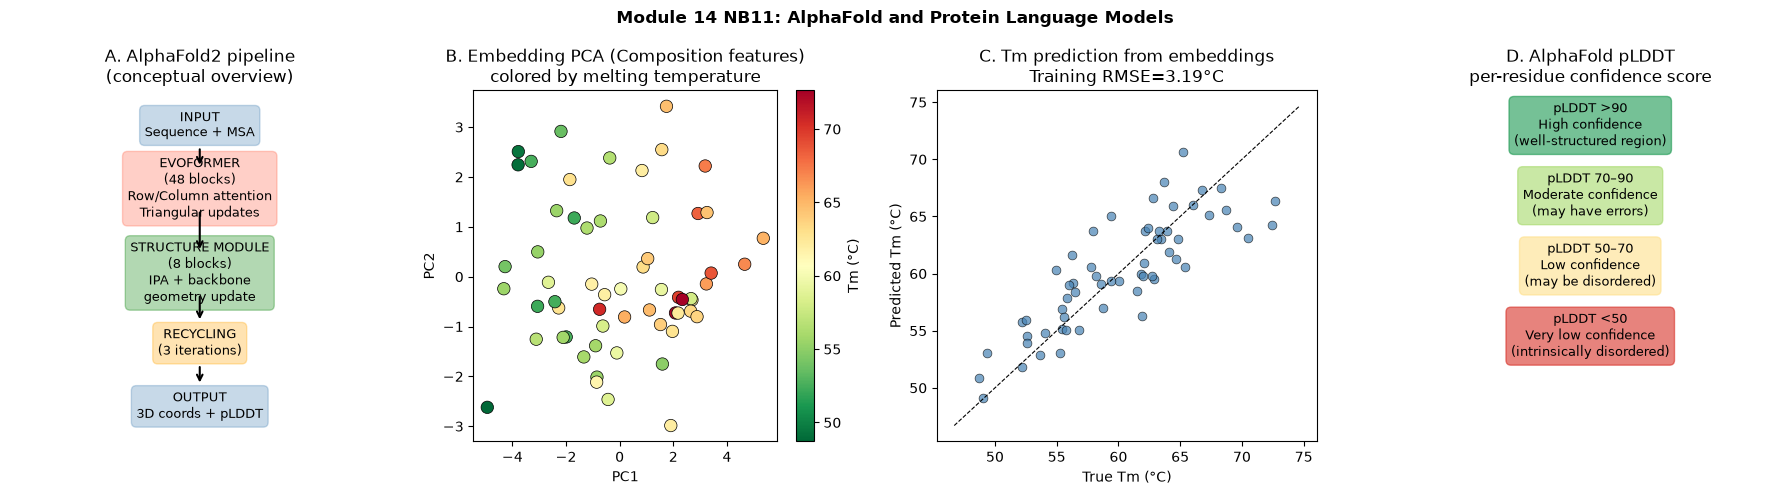

In [4]:
# Step 7 — Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Panel A: AlphaFold2 pipeline diagram
ax = axes[0]
ax.axis('off')
steps = [
    (0.5, 0.90, 'INPUT\nSequence + MSA', 'steelblue'),
    (0.5, 0.72, 'EVOFORMER\n(48 blocks)\nRow/Column attention\nTriangular updates', 'tomato'),
    (0.5, 0.48, 'STRUCTURE MODULE\n(8 blocks)\nIPA + backbone\ngeometry update', 'green'),
    (0.5, 0.28, 'RECYCLING\n(3 iterations)', 'orange'),
    (0.5, 0.10, 'OUTPUT\n3D coords + pLDDT', 'steelblue'),
]
for x, y, label, color in steps:
    ax.text(x, y, label, ha='center', va='center', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.3, edgecolor=color),
              transform=ax.transAxes)
for i in range(len(steps)-1):
    ax.annotate('', xy=(steps[i+1][0], steps[i+1][1]+0.06),
                   xytext=(steps[i][0], steps[i][1]-0.06),
                   xycoords='axes fraction', textcoords='axes fraction',
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.set_title('A. AlphaFold2 pipeline\n(conceptual overview)')

# Panel B: Embedding PCA colored by Tm
ax = axes[1]
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_emb)
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=Tm, cmap='RdYlGn_r', s=80, edgecolors='black', lw=0.5)
plt.colorbar(sc, ax=ax, label='Tm (°C)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
source = 'ESM-2' if ESM_AVAILABLE else 'Composition features'
ax.set_title(f'B. Embedding PCA ({source})\ncolored by melting temperature')

# Panel C: Predicted vs. actual Tm
ax = axes[2]
ax.scatter(Tm, Tm_pred, alpha=0.7, s=40, color='steelblue', edgecolors='black', lw=0.5)
lim = [Tm.min()-2, Tm.max()+2]
ax.plot(lim, lim, 'k--', lw=0.8)
rmse = np.sqrt(mean_squared_error(Tm, Tm_pred))
ax.set_xlabel('True Tm (°C)'); ax.set_ylabel('Predicted Tm (°C)')
ax.set_title(f'C. Tm prediction from embeddings\nTraining RMSE={rmse:.2f}°C')

# Panel D: pLDDT score interpretation diagram
ax = axes[3]
ax.axis('off')
plddt_info = [
    (0.90, '>90', 'High confidence\n(well-structured region)', '#1a9850'),
    (0.70, '70–90', 'Moderate confidence\n(may have errors)', '#a6d96a'),
    (0.50, '50–70', 'Low confidence\n(may be disordered)', '#fee08b'),
    (0.30, '<50', 'Very low confidence\n(intrinsically disordered)', '#d73027'),
]
for y, score, meaning, color in plddt_info:
    ax.text(0.5, y, f'pLDDT {score}\n{meaning}', ha='center', va='center', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.6, edgecolor=color),
              transform=ax.transAxes)
ax.set_title('D. AlphaFold pLDDT\nper-residue confidence score')

plt.suptitle('Module 14 NB11: AlphaFold and Protein Language Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('alphafold_language_models.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Exercises

1. If ESM is available: compute embeddings for 5 proteins from the same family
   (e.g., globins). Visualize the 2D PCA of their per-residue embeddings.
   Do structurally similar residues cluster together?
2. Explain the triangular multiplicative update in the evoformer. Why is it
   called "triangular" and what biological information does it encode?
3. What does a pLDDT score of 40 mean? Does it mean AlphaFold failed?
   Describe a biological context where low pLDDT is expected and informative.
4. Compute the zero-shot variant effect prediction: for a wildtype sequence and
   5 mutant variants, compute the log-likelihood ratio under a simple amino acid
   substitution matrix (BLOSUM62). Compare the ranking to the composition-based
   Tm predictions.

---
## Step 10 — Quiz

1. Name the four key components of the AlphaFold2 pipeline and describe what
   each computes.
2. What is the FAPE loss? Why is computing error in local reference frames
   better than computing error in global coordinates?
3. What is a protein language model? How does ESM-2 learn structural information
   without ever seeing 3D structures during training?
4. What is zero-shot variant effect prediction? What property of language models
   enables it?
5. What is the difference between AlphaFold2 and ESMFold? When would you prefer
   each?

---
## Step 12 — Reflection

> *[In one paragraph: explain why AlphaFold2 requires a Multiple Sequence Alignment
> (MSA) as input, what evolutionary information the MSA encodes, and why ESMFold's
> ability to work without an MSA is important for protein design applications
> where the designed sequence has no natural homologs.]*

---
*Next: `12_mini_project_and_assessment.ipynb`*